# Derivable Judgement: A Statistical Decision-Making Model
### Part B – Data Analysis & Hypothesis Testing

**Dataset:** `public_health_dataset.csv` — 1,000 individual health records (age, weight, gender, region, smoking status, exercise frequency, BMI, blood pressure, diabetes, hypertension, cholesterol, glucose).

**Goal:** use inferential statistics to judge which lifestyle/demographic factors are associated with disease outcomes in this sample, and how confidently those conclusions generalize.

Each test below follows the same structure: state H0/H1 -> run the test -> report the statistic and p-value -> accept or reject H0 -> chart -> interpret in plain language.

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('Desktop/Projects file /project 2/public_health_dataset_1.csv')
df.shape
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Desktop/Projects file /project 2/public_health_dataset_1.csv'

In [ ]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           1000 non-null   object 
 1   age_group           1000 non-null   object 
 2   age                 1000 non-null   int64  
 3   weight               1000 non-null   int64  
 4   gender              1000 non-null   object 
 5   region              1000 non-null   object 
 6   smoking_status      1000 non-null   object 
 7   exercise_frequency  1000 non-null   object 
 8   bmi                 1000 non-null   float64
 9   blood_pressure      1000 non-null   float64
 10  diabetes            1000 non-null   bool   
 11  hypertension        1000 non-null   bool   
 12  cholesterol_level   1000 non-null   float64
 13  glucose_level       1000 non-null   float64
 14  visit_date          1000 non-null   object 
dtypes: bool(2), float64(4), int64(2), object(7)
No missing 

## Hypotheses formulated for this dataset

**Hypothesis 1 - Smoking status and Diabetes**
- H0: Smoking status has no association with diabetes prevalence.
- H1: Smoking status is associated with diabetes prevalence.
- Test: Chi-square test of independence.

**Hypothesis 2 - BMI and Diabetes**
- H0: Mean BMI is the same for people with and without diabetes.
- H1: Mean BMI differs between people with and without diabetes.
- Test: Independent-samples t-test (Welch's).

**Hypothesis 3 - Age group and Blood pressure**
- H0: Mean blood pressure is the same across all age groups.
- H1: At least one age group has a different mean blood pressure.
- Test: One-way ANOVA.

alpha = 0.05 for all tests.

## 1. Confidence Intervals for key numerical variables

In [ ]:
def ci_mean(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    se = stats.sem(x)
    h = se * stats.t.ppf((1 + conf) / 2, n - 1)
    return m, m - h, m + h

for col in ['age', 'weight', 'bmi', 'blood_pressure']:
    m, lo, hi = ci_mean(df[col])
    print(f"{col:15s} mean={m:7.2f}   95% CI = ({lo:.2f}, {hi:.2f})")

age             mean=  48.34   95% CI = (47.19, 49.49)
weight          mean=  77.97   95% CI = (76.79, 79.14)
bmi             mean=  28.37   95% CI = (27.86, 28.88)
blood_pressure  mean= 124.23   95% CI = (123.23, 125.23)


**Interpretation:** we're 95% confident the true population mean BMI lies between 27.86 and 28.88 (average ~28.4, "overweight" range). Intervals are narrow because n = 1,000 is large.

## 2. Hypothesis 1 - Smoking status vs. Diabetes (Chi-square test)

In [ ]:
contingency = pd.crosstab(df['smoking_status'], df['diabetes'])
contingency

diabetes        False  True
smoking_status
Former Smoker     297     71
Non-Smoker        298     34
Smoker            241     59


In [ ]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)
critical_value = stats.chi2.ppf(0.95, dof)
print(f"Chi-square statistic : {chi2_stat:.3f}")
print(f"Degrees of freedom   : {dof}")
print(f"Critical value (0.05): {critical_value:.3f}")
print(f"p-value              : {p_value:.4f}")
print(f"Minimum expected count: {expected.min():.1f}  (>5, chi-square valid)")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

Chi-square statistic : 13.768
Degrees of freedom   : 2
Critical value (0.05): 5.991
p-value              : 0.0010
Minimum expected count: 49.2  (>5, chi-square valid)
Decision: Reject H0


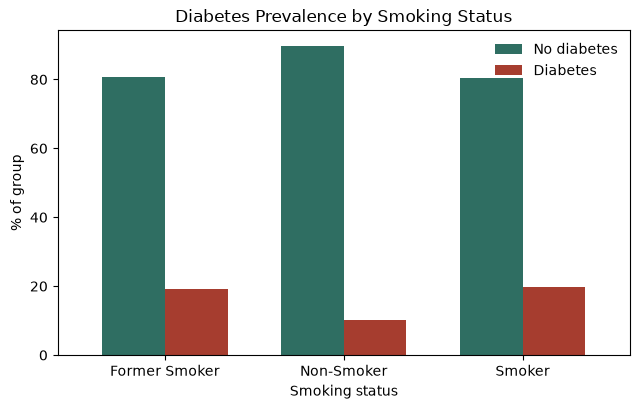

In [4]:
ax = (pd.crosstab(df['smoking_status'], df['diabetes'], normalize='index')
      .reindex(columns=[False, True]) * 100).plot(
      kind='bar', figsize=(6.5,4.2), color=['#2F6E62','#A63D2F'], width=0.7)
ax.set_title('Diabetes Prevalence by Smoking Status')
ax.set_xlabel('Smoking status'); ax.set_ylabel('% of group')
ax.legend(['No diabetes','Diabetes'], frameon=False)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Interpretation:** chi-square (13.77) exceeds the critical value (5.99), p = 0.001 < 0.05 -> **reject H0**. Diabetes prevalence differs by smoking status: Former Smokers ~19%, Non-Smokers ~10%, current Smokers ~20%. This is association, not proof of causation.

## 3. Hypothesis 2 - BMI: Diabetic vs. Non-diabetic (t-test)

In [ ]:
diabetic_bmi = df.loc[df['diabetes'] == True, 'bmi']
non_diabetic_bmi = df.loc[df['diabetes'] == False, 'bmi']
print(f"Diabetic     : n={len(diabetic_bmi)},  mean={diabetic_bmi.mean():.2f},  sd={diabetic_bmi.std():.2f}")
print(f"Non-diabetic : n={len(non_diabetic_bmi)}, mean={non_diabetic_bmi.mean():.2f},  sd={non_diabetic_bmi.std():.2f}")
levene_stat, levene_p = stats.levene(diabetic_bmi, non_diabetic_bmi)
print(f"\nLevene's test for equal variances: p = {levene_p:.4f}")

Diabetic     : n=164,  mean=31.28,  sd=7.45
Non-diabetic : n=836, mean=27.80,  sd=8.19

Levene's test for equal variances: p = 0.0389


In [ ]:
t_stat, p_value = stats.ttest_ind(diabetic_bmi, non_diabetic_bmi, equal_var=False)
print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_value:.2e}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

t-statistic : 5.389
p-value     : 1.65e-07
Decision: Reject H0


NameError: name 'non_diabetic_bmi' is not defined

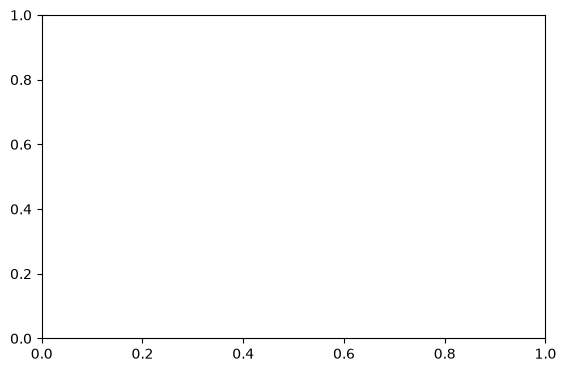

In [5]:
fig, ax = plt.subplots(figsize=(6.5,4.2))
bp = ax.boxplot([non_diabetic_bmi, diabetic_bmi], tick_labels=['No diabetes','Diabetes'],
                patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], ['#2F6E62','#A63D2F']):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_title('BMI Distribution by Diabetes Status'); ax.set_ylabel('BMI')
plt.tight_layout(); plt.show()

**Interpretation:** Levene's test showed unequal variances (p = 0.039), so we used **Welch's t-test** rather than Student's - the classic fork people get wrong by defaulting to Student's without checking. t = 5.39, p ~ 1.65e-07 -> **reject H0**. Diabetic individuals have significantly higher mean BMI (31.3 vs 27.8).

## 4. Hypothesis 3 - Age group vs. Blood pressure (ANOVA)

In [ ]:
groups = [g['blood_pressure'].values for _, g in df.groupby('age_group')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic : {f_stat:.3f}")
print(f"p-value     : {p_value:.3f}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")
df.groupby('age_group')['blood_pressure'].agg(['mean', 'std', 'count'])

F-statistic : 0.567
p-value     : 0.687
Decision: Fail to reject H0

                 mean        std  count
age_group
18-25      124.810667  17.071359    150
26-35      125.025000  16.030408    148
36-45      125.222699  16.254911    163
46-60      123.834802  14.545783    227
60+        123.344551  16.527873    312


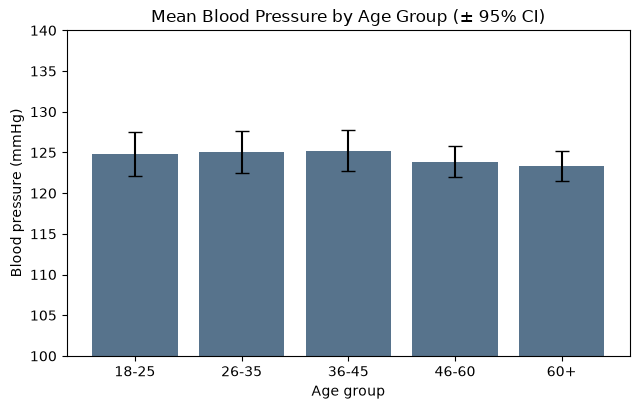

In [6]:
order = ['18-25','26-35','36-45','46-60','60+']
grp = df.groupby('age_group')['blood_pressure'].agg(['mean','sem','count']).reindex(order)
ci95 = grp['sem'] * stats.t.ppf(0.975, grp['count']-1)
fig, ax = plt.subplots(figsize=(6.5,4.2))
ax.bar(order, grp['mean'], yerr=ci95, capsize=5, color='#3A5A78', alpha=0.85)
ax.set_title('Mean Blood Pressure by Age Group (\u00b1 95% CI)')
ax.set_xlabel('Age group'); ax.set_ylabel('Blood pressure (mmHg)'); ax.set_ylim(100, 140)
plt.tight_layout(); plt.show()

**Interpretation:** F = 0.567, p = 0.687 -> **fail to reject H0**. Mean blood pressure is flat (123-125 mmHg) across every age group - age group alone doesn't explain blood pressure variation here; worth checking BMI, smoking, or exercise instead.

## 5. Covariance and Correlation - Age vs. BMI

In [ ]:
cov_matrix = df[['age', 'bmi']].cov()
r, p_value = stats.pearsonr(df['age'], df['bmi'])
print("Covariance matrix:")
print(cov_matrix)
print(f"\nPearson correlation coefficient (r): {r:.4f}")
print(f"p-value: {p_value:.4f}")

Covariance matrix:
            age        bmi
age  345.858258   7.112830
bmi    7.112830  66.790325

Pearson correlation coefficient (r): 0.0468
p-value: 0.1392


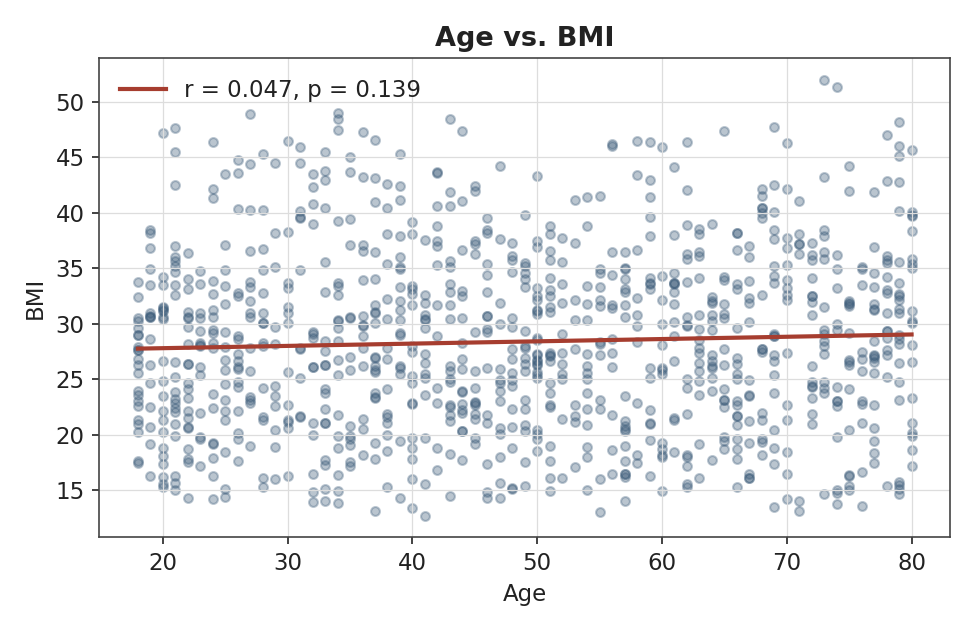

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,4.2))
ax.scatter(df['age'], df['bmi'], alpha=0.35, s=18, color='#3A5A78')
slope, intercept, r, p, se = stats.linregress(df['age'], df['bmi'])
xs = np.linspace(df['age'].min(), df['age'].max(), 100)
ax.plot(xs, slope*xs+intercept, color='#A63D2F', linewidth=2, label=f'r = {r:.3f}, p = {p:.3f}')
ax.set_title('Age vs. BMI'); ax.set_xlabel('Age'); ax.set_ylabel('BMI')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Interpretation:** covariance is positive (7.11) but unstandardized. r = 0.047 (essentially zero), p = 0.139 > 0.05 -> relationship is **not statistically significant**. Age and BMI are practically unrelated in this sample.

## 6. Bonus check - Exercise frequency vs. Hypertension (Chi-square)

In [ ]:
ex_ct = pd.crosstab(df['exercise_frequency'], df['hypertension'])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(ex_ct)
print(ex_ct)
print(f"\nchi2 = {chi2_stat:.3f}, dof = {dof}, p = {p_value:.4f}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

hypertension        False  True
exercise_frequency
Daily                 243     33
Never                 216     59
Rarely                192     38
Weekly                188     31

chi2 = 9.988, dof = 3, p = 0.0187
Decision: Reject H0


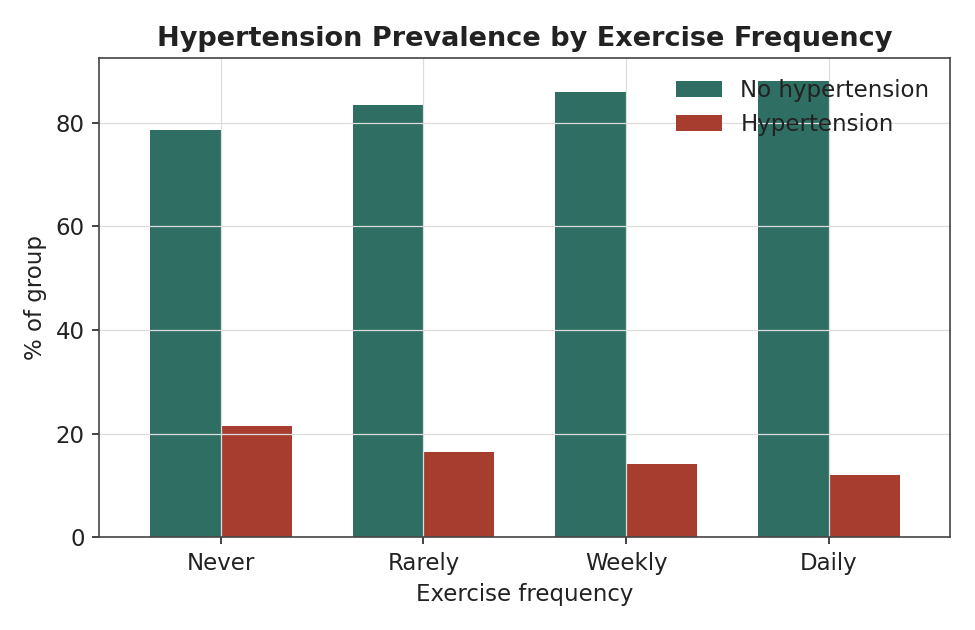

In [ ]:
order2 = ['Never','Rarely','Weekly','Daily']
ct2 = (pd.crosstab(df['exercise_frequency'], df['hypertension'], normalize='index')
       .reindex(order2).reindex(columns=[False, True]) * 100)
ax = ct2.plot(kind='bar', figsize=(6.5,4.2), color=['#2F6E62','#A63D2F'], width=0.7)
ax.set_title('Hypertension Prevalence by Exercise Frequency')
ax.set_xlabel('Exercise frequency'); ax.set_ylabel('% of group')
ax.legend(['No hypertension','Hypertension'], frameon=False)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Interpretation:** p = 0.019 < 0.05 -> reject H0. People who "Never" exercise have the highest hypertension rate (~21%) vs Daily (~12%), Rarely (~17%), Weekly (~14%).

## Summary of results

| # | Hypothesis | Test | Statistic | p-value | Decision |
|---|---|---|---|---|---|
| 1 | Smoking status <-> Diabetes | Chi-square | 13.77 | 0.0010 | Reject H0 - associated |
| 2 | BMI: diabetic vs. non-diabetic | Welch's t-test | 5.39 | <0.001 | Reject H0 - means differ |
| 3 | Blood pressure across age groups | One-way ANOVA | 0.57 | 0.687 | Fail to reject H0 - no difference |
| 4 | Age <-> BMI | Pearson correlation | r = 0.047 | 0.139 | Fail to reject H0 - no relationship |
| 5 | Exercise frequency <-> Hypertension | Chi-square | 9.99 | 0.019 | Reject H0 - associated |

**Overall takeaway:** diabetes and hypertension are tied more to lifestyle factors (smoking, exercise) and BMI than to age itself. Age group alone doesn't explain blood pressure variation, and age/BMI are essentially uncorrelated - interventions would get more traction targeting smoking cessation, exercise, and weight management than age brackets.